# UMAP

Ноутбук:
1. Импорт библиотек
2. Данные (Digits)
3. Зачем нужен UMAP
4. PCA / t-SNE / UMAP — 2D-проекции
5. Влияние `n_neighbors` (количество соседей)
6. Влияние `min_dist`
7. UMAP vs t-SNE — сходства и различия

## 1. Импорт библиотек

In [12]:
import umap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

## 2. Данные

Берём датасет `digits` (рукописные цифры 8*8 = 64 признака, 10 классов).
Он маленький, наглядный и хорошо показывает разницу между методами.


In [13]:
digits = load_digits()
X, y = digits.data, digits.target
X = StandardScaler().fit_transform(X)

print("Размер X:", X.shape)
print("Классы:", np.unique(y))


Размер X: (1797, 64)
Классы: [0 1 2 3 4 5 6 7 8 9]


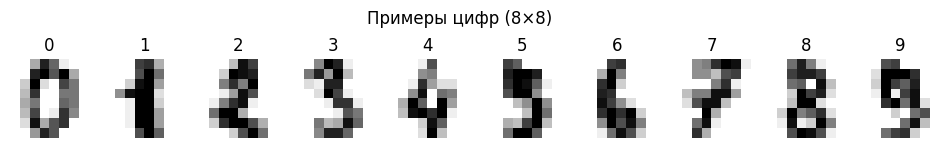

In [14]:
fig, axes = plt.subplots(1, 10, figsize=(12, 1.6))
for i, ax in enumerate(axes):
    ax.imshow(digits.images[i], cmap="gray_r")
    ax.set_title(digits.target[i])
    ax.axis("off")
plt.suptitle("Примеры цифр (8×8)", y=1.05)
plt.show()


## 3. Зачем нужен UMAP

- В исходных данных **64 признака** — глазами не посмотришь.
- Хочется увидеть **структуру**: какие классы рядом, есть ли кластеры.
- **PCA** — линейный, быстро, но плохо ловит нелинейные многообразия.
- **t-SNE** — отлично рисует кластеры, но **медленный** и плохо сохраняет глобальную структуру.
- **UMAP** — быстрый, лучше сохраняет и **локальную, и глобальную** структуру,
  и может работать как универсальный препроцессор для ML.


## 4. PCA, t-SNE, UMAP — 2D-проекции

Делаем три проекции на одних и тех же данных и рисуем рядом.


In [15]:
def scatter2d(ax, emb, y, title):
    sc = ax.scatter(emb[:, 0], emb[:, 1], c=y, cmap="tab10", s=8, alpha=0.85)
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])
    return sc


In [16]:
pca_emb = PCA(n_components=2, random_state=42).fit_transform(X)

tsne_emb = TSNE(n_components=2, perplexity=30, random_state=42, init="pca", learning_rate="auto").fit_transform(X)

umap_emb = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(X)
umap_title = "UMAP (n_neighbors=15, min_dist=0.1)"


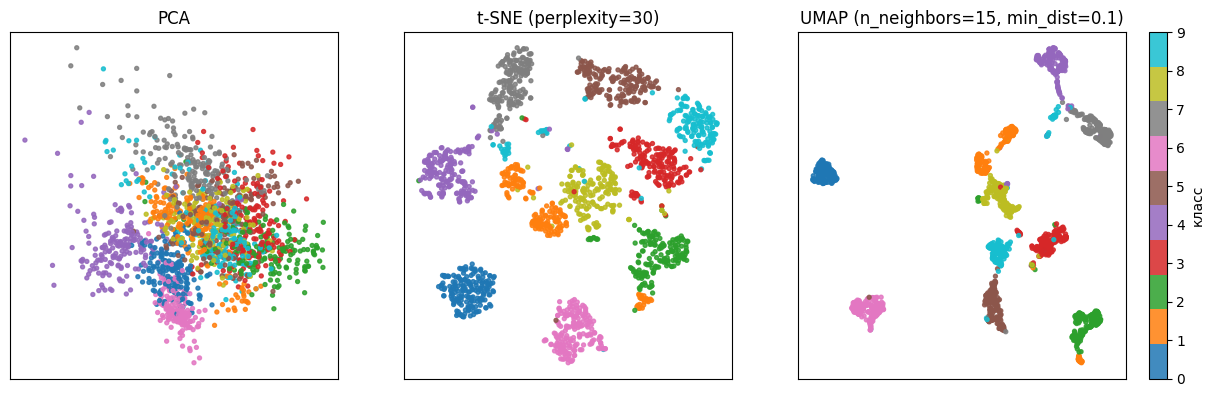

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
scatter2d(axes[0], pca_emb,  y, "PCA")
scatter2d(axes[1], tsne_emb, y, "t-SNE (perplexity=30)")
sc = scatter2d(axes[2], umap_emb, y, umap_title)
fig.colorbar(sc, ax=axes, fraction=0.02, pad=0.02, ticks=range(10), label="класс")
plt.show()


**Что видно:**
- PCA даёт «облако» — классы перемешаны, видна только грубая структура.
- t-SNE красиво разделяет цифры на компактные кластеры.
- UMAP — кластеры тоже чёткие, но взаимное расположение групп
  (глобальная структура) обычно осмысленнее, чем у t-SNE.


## 5. Влияние `n_neighbors` (количество гостей)

`n_neighbors` управляет балансом **локальное ↔ глобальное**:
- маленькое значение (~5) — UMAP смотрит на ближайших соседей →
  подчёркивает мелкую локальную структуру, кластеры дробятся;
- большое значение (~50–200) — UMAP усредняет по большой окрестности →
  глобальная картина, но детали теряются.


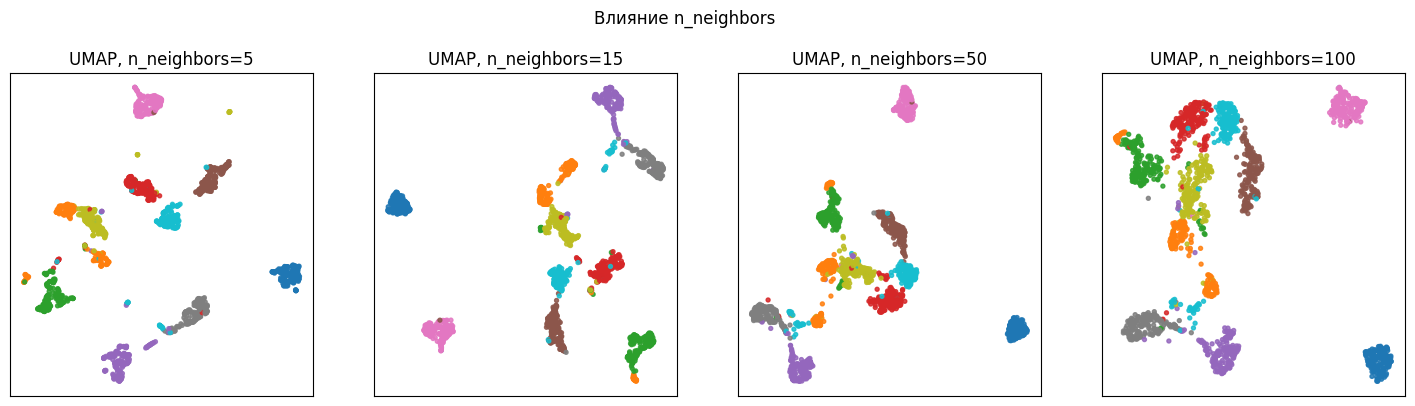

In [18]:
neighbors_list = [5, 15, 50, 100]

fig, axes = plt.subplots(1, 4, figsize=(18, 4.2))
for ax, n in zip(axes, neighbors_list):
    emb = umap.UMAP(n_neighbors=n, min_dist=0.1, random_state=42).fit_transform(X)

    title = f"UMAP, n_neighbors={n}"

    scatter2d(ax, emb, y, title)
plt.suptitle("Влияние n_neighbors", y=1.03)
plt.show()


## 6. Влияние `min_dist`

`min_dist` — минимально допустимое расстояние между точками в проекции:
- маленькое (~0.0–0.1) — точки внутри кластера прижимаются друг к другу,
  кластеры выглядят плотными «комками»;
- большое (~0.5–0.99) — точки расталкиваются, кластеры более «пушистые»
  и равномерно распределённые.


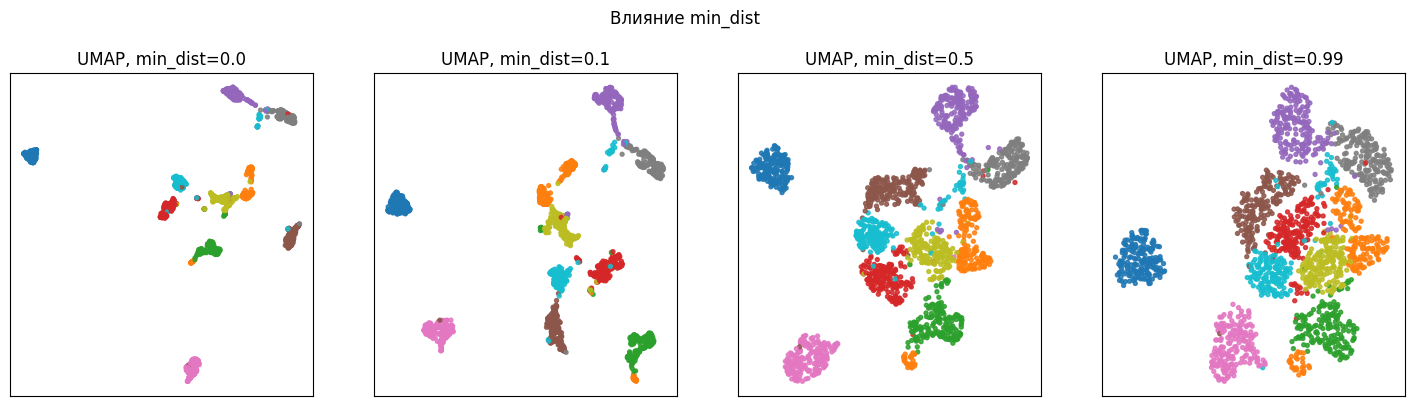

In [19]:
mindist_list = [0.0, 0.1, 0.5, 0.99]

fig, axes = plt.subplots(1, 4, figsize=(18, 4.2))
for ax, md_ in zip(axes, mindist_list):
    emb = umap.UMAP(n_neighbors=15, min_dist=md_, random_state=42).fit_transform(X)

    title = f"UMAP, min_dist={md_}"

    scatter2d(ax, emb, y, title)
plt.suptitle("Влияние min_dist", y=1.03)
plt.show()


## 7. UMAP vs t-SNE

**Похожи:**
- оба нелинейные;
- оба строят граф ближайших соседей и оптимизируют расположение в 2D/3D;
- оба отлично рисуют локальные кластеры.

**Отличаются:**
- **Скорость:** t-SNE медленный на больших данных, UMAP быстрее;
- **Глобальная структура:** t-SNE почти не сохраняет, UMAP сохраняет лучше;
- **Параметры:** у t-SNE — `perplexity`, у UMAP — `n_neighbors`, `min_dist`;
- **Новые точки:** у t-SNE нет `transform` из коробки, у UMAP есть;
- **Применение:** t-SNE — в основном визуализация, UMAP — визуализация и препроцессинг.

#**Общий итог:**

- **PCA** — самый простой и быстрый способ первым делом посмотреть на структуру данных. Он хорошо подходит как базовый метод снижения размерности и предварительный анализ.
- **t-SNE** — хороший выбор для красивой и детальной визуализации небольших датасетов, особенно когда важно увидеть локальные кластеры.
- **UMAP** — чаще лучше подходит для больших данных: он быстрее t-SNE, лучше сохраняет глобальную структуру и может использоваться не только для визуализации, но и как шаг препроцессинга в ML-пайплайне.
